# ConvNeXt-large fine-tuned on FER+: an architecturally complementary branch

Fine-tunes `facebook/convnext-large-224-22k-1k` (ConvNeXt-large, 198M params,
ImageNet-22k pretrain) on the 8-class FER+ relabeling of FER2013. This model is
trained as a deliberate counterpart to the face-pretrained ViT in `01_train_vit_face.ipynb`:
its hierarchical CNN inductive bias and ImageNet pretraining produce
**architecturally and pretrain-domain orthogonal** features, which is what
ensembling exploits.

Single-model test accuracy after TTA: **0.852** (macro-F1 **0.676**). The
combined v6+v7 ensemble (see `03_ensemble_inference.ipynb`) reaches **0.863 / 0.731**.

In [1]:
# Dependencies (Colab). Uncomment if running outside a fresh Colab runtime.
# %pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# %pip install -q transformers pandas numpy pillow scikit-learn matplotlib seaborn tqdm


In [2]:
import os, random, math
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (AutoImageProcessor, AutoConfig,
                          ConvNextForImageClassification,
                          get_cosine_schedule_with_warmup)


In [3]:
from google.colab import drive
drive.mount('/content/drive')
csv_fer  = '/content/drive/MyDrive/datasets/fer2013-original.csv'
csv_plus = '/content/drive/MyDrive/datasets/fer2013new.csv'
ckpt_dir = Path('/content/drive/MyDrive/checkpoints')
ckpt_dir.mkdir(parents=True, exist_ok=True)


Mounted at /content/drive


In [4]:
import warnings
warnings.filterwarnings("ignore")


## Dataset: FER+

Same preprocessing as `01_train_vit_face.ipynb`: FER+ vote distributions joined to
FER2013 pixels, with rows where `unknown + NF` votes outweigh emotion votes
discarded. The retained 35 625 images split as 28 493 train / 3 569 val
(PublicTest) / 3 563 test (PrivateTest). Soft labels are the normalized vote
distributions; hard labels (argmax) are used only for metrics.

In [7]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

# --- Backbone ---
BACKBONE = "facebook/convnext-large-224-22k-1k"   # 198M params, ImageNet-22k pretrain

# --- Runtime ---
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2
BATCH = 16            # T4 16GB cannot fit 32 at this size
PRED_BATCH = 64

# --- Training ---
EPOCHS_HEAD = 5
EPOCHS_FULL = 60      # larger model converges slower; more headroom
LR_HEAD = 5e-4
LR_BACKBONE_MAX = 5e-6   # scaled down vs base (more params, smaller batch)
LLRD_FACTOR = 0.8
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
PATIENCE = 12
LABEL_SMOOTH = 0.05

# --- Regularization ---
DROP_PATH_RATE = 0.2   # ConvNeXt paper recommends >=0.2 for the large variant
HEAD_DROPOUT = 0.3
EMA_DECAY = 0.9999

# --- Augmentation ---
USE_RAND_AUGMENT = True
RAND_AUG_N = 2
RAND_AUG_M = 7

USE_MIXUP_CUTMIX = True
MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0
MIX_PROB = 0.5

# --- Class weighting ---
USE_CLASS_WEIGHTS = True
CW_ALPHA = 0.4

# --- Classes ---
FERP_CLASSES = ['neutral','happiness','surprise','sadness','anger','disgust','fear','contempt']
FERP_DISPLAY = ['Neutral','Happy','Surprise','Sad','Angry','Disgust','Fear','Contempt']
NUM_CLASSES = len(FERP_CLASSES)
EMO_COLS = FERP_CLASSES
EXTRA_COLS = ['unknown','nf']
ALL_VOTE_COLS = EMO_COLS + EXTRA_COLS

torch.backends.cudnn.benchmark = True
if DEVICE == 'cuda':
    try: torch.set_float32_matmul_precision('high')
    except: pass

print(f'Device: {DEVICE} | Backbone: {BACKBONE}')


Device: cuda | Backbone: facebook/convnext-large-224-22k-1k


In [8]:
# Join FER2013 pixels with FER+ vote distributions; filter unknown / NF majorities.
fer_df  = pd.read_csv(csv_fer)
plus_df = pd.read_csv(csv_plus)
assert len(fer_df) == len(plus_df), (len(fer_df), len(plus_df))

plus_df.columns = [c.strip() for c in plus_df.columns]
rename_map = {}
for c in plus_df.columns:
    cl = c.lower()
    if cl in [s.lower() for s in ALL_VOTE_COLS] + ['usage','image name']:
        rename_map[c] = cl.replace(' ', '_') if cl == 'image name' else cl
plus_df = plus_df.rename(columns=rename_map)

for c in ALL_VOTE_COLS:
    if c not in plus_df.columns:
        raise ValueError(f'Missing column {c!r} in fer2013new.csv. Found: {list(plus_df.columns)}')

votes = plus_df[ALL_VOTE_COLS].values.astype(np.float32)
emo_votes   = votes[:, :NUM_CLASSES]
extra_votes = votes[:, NUM_CLASSES:]
total_emo = emo_votes.sum(axis=1)
keep_mask = (total_emo > 0) & (extra_votes.sum(axis=1) < total_emo)

joined = pd.DataFrame({'pixels': fer_df['pixels'].values, 'Usage': fer_df['Usage'].values})
for c in EMO_COLS:
    joined[c] = plus_df[c].values
joined = joined[keep_mask].reset_index(drop=True)

e = joined[EMO_COLS].values.astype(np.float32)
soft = e / np.maximum(e.sum(axis=1, keepdims=True), 1.0)
joined['hard'] = soft.argmax(axis=1)
joined['soft'] = list(soft)

train_df = joined[joined['Usage']=='Training'].reset_index(drop=True)
val_df   = joined[joined['Usage']=='PublicTest'].reset_index(drop=True)
test_df  = joined[joined['Usage']=='PrivateTest'].reset_index(drop=True)

print(f'Total kept: {len(joined)}/{len(fer_df)} | Train/Val/Test: {len(train_df)}/{len(val_df)}/{len(test_df)}')


Total kept: 35625/35887 | Train/Val/Test: 28493/3569/3563


In [9]:
def decode_row_pixels(pixels_str):
    vals = np.asarray(pixels_str.split(), dtype=np.uint8)
    return Image.fromarray(np.stack([vals.reshape(48, 48)]*3, axis=-1), mode='RGB')


## Data pipeline

Identical augmentation strategy to the ViT notebook (single 48->224 resize then
RandAugment + ColorJitter + RandomResizedCrop + RandomErasing). The ConvNeXt
processor's mean/std are the standard ImageNet values.

In [10]:
import torchvision.transforms as T

processor = AutoImageProcessor.from_pretrained(BACKBONE)
IMG_SIZE = processor.size.get('shortest_edge', processor.size.get('height', 224))
MEAN = processor.image_mean; STD = processor.image_std
print(f'Input: {IMG_SIZE}x{IMG_SIZE} | mean={MEAN} | std={STD}')

_pre_resize = T.Resize((IMG_SIZE, IMG_SIZE))
_aug_pil = [
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=8),
    T.ColorJitter(brightness=0.2, contrast=0.2),
]
if USE_RAND_AUGMENT:
    _aug_pil.append(T.RandAugment(num_ops=RAND_AUG_N, magnitude=RAND_AUG_M))
train_pil_aug = T.Compose([_pre_resize] + _aug_pil + [
    T.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
])
_to_tensor = T.Compose([T.ToTensor(), T.Normalize(mean=MEAN, std=STD)])
_random_erasing = T.RandomErasing(p=0.25, scale=(0.02, 0.15), ratio=(0.3, 3.3), value=0.0)

def preprocess_train(pil_img):
    return _random_erasing(_to_tensor(train_pil_aug(pil_img)))

def preprocess_test_pil(pil_img):
    return _to_tensor(_pre_resize(pil_img))

class FERPTrainDataset(Dataset):
    def __init__(self, frame):
        self.pixels = frame['pixels'].values
        self.soft = np.stack(frame['soft'].values).astype(np.float32)
    def __len__(self): return len(self.pixels)
    def __getitem__(self, idx):
        return preprocess_train(decode_row_pixels(self.pixels[idx])), torch.from_numpy(self.soft[idx])

def train_collate(batch):
    xs = torch.stack([b[0] for b in batch])
    ys = torch.stack([b[1] for b in batch])
    return {'pixel_values': xs}, ys

train_loader = DataLoader(
    FERPTrainDataset(train_df), batch_size=BATCH, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=train_collate,
    pin_memory=True, prefetch_factor=4 if NUM_WORKERS>0 else None,
    persistent_workers=NUM_WORKERS>0,
)

def build_cached_loader(frame, batch_size):
    tensors = [preprocess_test_pil(decode_row_pixels(p)) for p in frame['pixels'].tolist()]
    X = torch.stack(tensors)
    soft_y = torch.from_numpy(np.stack(frame['soft'].values).astype(np.float32))
    hard_y = torch.from_numpy(frame['hard'].values.astype(np.int64))
    ds = TensorDataset(X, soft_y, hard_y)
    def collate(batch):
        return ({'pixel_values': torch.stack([b[0] for b in batch])},
                torch.stack([b[1] for b in batch]),
                torch.stack([b[2] for b in batch]))
    return DataLoader(ds, batch_size=batch_size, shuffle=False,
                      num_workers=NUM_WORKERS, collate_fn=collate,
                      pin_memory=True, prefetch_factor=4 if NUM_WORKERS>0 else None,
                      persistent_workers=NUM_WORKERS>0)

val_loader  = build_cached_loader(val_df,  PRED_BATCH)
test_loader = build_cached_loader(test_df, PRED_BATCH)
print(f'Steps/epoch: {len(train_loader)} | val batches: {len(val_loader)} | test batches: {len(test_loader)}')


preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

The image processor of type `ConvNextImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Input: 224x224 | mean=[0.485, 0.456, 0.406] | std=[0.229, 0.224, 0.225]
Steps/epoch: 1781 | val batches: 56 | test batches: 56


## Backbone: ConvNeXt-large

`facebook/convnext-large-224-22k-1k` (Liu et al., CVPR 2022) is a 4-stage
hierarchical ConvNet with `depths=[3,3,27,3]` and `widths=[192,384,768,1536]`,
198M params, pretrained on ImageNet-22k and fine-tuned on ImageNet-1k. Compared
to ViT, ConvNeXt provides:

- A locality-biased inductive prior — useful for fine facial detail at 224 resolution.
- Disjoint pretrain corpus (ImageNet) — uncorrelated supervised signal vs the
  face-pretrained ViT, which yields error decorrelation under ensembling.
- Larger parameter count (198M vs 86M).

`drop_path_rate=0.2` is used per the ConvNeXt paper's recommendation for the
large variant; lower values overfit on FER+ given the small effective batch
size. The 1000-class ImageNet head is replaced with `Dropout(0.3) -> Linear(8)`.

In [11]:
id2label = {i: FERP_CLASSES[i] for i in range(NUM_CLASSES)}
label2id = {v:k for k,v in id2label.items()}
cfg = AutoConfig.from_pretrained(
    BACKBONE, num_labels=NUM_CLASSES,
    id2label=id2label, label2id=label2id,
    drop_path_rate=DROP_PATH_RATE,
)
model = ConvNextForImageClassification.from_pretrained(
    BACKBONE, config=cfg, ignore_mismatched_sizes=True
).to(DEVICE)

hidden = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=HEAD_DROPOUT),
    nn.Linear(hidden, NUM_CLASSES),
).to(DEVICE)
nn.init.trunc_normal_(model.classifier[1].weight, std=0.02)
nn.init.zeros_(model.classifier[1].bias)

print(f'Params: {sum(p.numel() for p in model.parameters()):,} | Drop path: {DROP_PATH_RATE}')


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/791M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/344 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-large-224-22k-1k
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 1536]) vs model:torch.Size([8, 1536])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([8])            

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/791M [00:00<?, ?B/s]

Params: 196,242,632 | Drop path: 0.2


## Loss: weighted soft cross-entropy

Identical formulation to notebook 01: per-sample cross-entropy against the soft
target distribution (potentially mixed by MixUp/CutMix), each sample rescaled by
its expected class weight. `CW_ALPHA=0.4` is slightly stronger than the ViT's
`0.3` since ConvNeXt-large without class re-balancing tends to collapse rare
classes more aggressively on this data.

In [12]:
counts = np.bincount(train_df['hard'].values.astype(np.int64), minlength=NUM_CLASSES).astype(np.float64)
inv_sqrt = 1.0 / np.sqrt(np.maximum(counts, 1.0))
inv_sqrt = inv_sqrt / inv_sqrt.mean()
cw_np = (1.0 - CW_ALPHA) * np.ones_like(inv_sqrt) + CW_ALPHA * inv_sqrt
class_weights = torch.tensor(cw_np, dtype=torch.float32, device=DEVICE)
print('Per-class weights (alpha={:.2f}):'.format(CW_ALPHA),
      {FERP_DISPLAY[i]: round(float(class_weights[i]), 3) for i in range(NUM_CLASSES)})

class WeightedSoftCrossEntropy(nn.Module):
    def __init__(self, weight=None, label_smoothing=0.0):
        super().__init__()
        self.weight = weight
        self.ls = label_smoothing
    def forward(self, logits, target_soft):
        if self.ls > 0:
            n = logits.size(-1)
            target_soft = (1.0 - self.ls) * target_soft + self.ls / n
        log_probs = F.log_softmax(logits, dim=-1)
        nll = -(target_soft * log_probs).sum(dim=-1)
        if self.weight is not None:
            sample_w = (target_soft * self.weight.view(1, -1)).sum(dim=-1)
            return (nll * sample_w).sum() / sample_w.sum().clamp_min(1e-6)
        return nll.mean()

criterion = WeightedSoftCrossEntropy(
    weight=class_weights if USE_CLASS_WEIGHTS else None,
    label_smoothing=LABEL_SMOOTH,
)


Per-class weights (alpha=0.40): {'Neutral': 0.719, 'Happy': 0.74, 'Surprise': 0.803, 'Sad': 0.804, 'Angry': 0.844, 'Disgust': 1.473, 'Fear': 1.075, 'Contempt': 1.541}


## Training recipe

| Component | Setting |
|---|---|
| Optimizer | AdamW, weight decay 0.05 (zero on bias / LayerNorm) |
| LR (head) | 5e-4 |
| LR (backbone, top stage) | 5e-6 |
| LLRD factor | 0.8 over 4 ConvNeXt stages |
| Schedule | cosine, 10% warmup |
| Head dropout | 0.3 |
| Stochastic depth (drop_path) | 0.2 |
| MixUp / CutMix | alpha=0.4 / alpha=1.0, 50% per batch, alternated |
| Label smoothing | 0.05 |
| EMA decay | 0.9999 |
| Gradient clipping | max-norm 1.0 |
| Mixed precision | fp16 |
| Batch | 16 (T4 memory) |
| Epochs | 5 head-only + up to 60 full, patience 12 |

LLRD over the 4 ConvNeXt stages descends from `5e-6` (top stage) to
`5e-6 * 0.8^3 = 2.56e-6` (bottom stage), with the embeddings (downsampling stem)
at `2.05e-6`.

In [13]:
def is_no_decay(name):
    return name.endswith('.bias') or ('layernorm' in name.lower()) or ('layer_norm' in name.lower())

def make_groups_simple(named_params, lr):
    decay, no_decay = [], []
    for n, p in named_params:
        if not p.requires_grad: continue
        (no_decay if is_no_decay(n) else decay).append(p)
    groups = []
    if decay:    groups.append({"params": decay, "lr": lr, "weight_decay": WEIGHT_DECAY})
    if no_decay: groups.append({"params": no_decay, "lr": lr, "weight_decay": 0.0})
    return groups

def make_convnext_llrd_groups(model, lr_head, lr_backbone_max, llrd_factor):
    groups = []
    groups += make_groups_simple(model.classifier.named_parameters(), lr_head)
    num_stages = len(model.convnext.encoder.stages)
    for stage_idx in range(num_stages - 1, -1, -1):
        depth_from_top = (num_stages - 1) - stage_idx
        lr = lr_backbone_max * (llrd_factor ** depth_from_top)
        groups += make_groups_simple(model.convnext.encoder.stages[stage_idx].named_parameters(), lr)
    embed_lr = lr_backbone_max * (llrd_factor ** num_stages)
    groups += make_groups_simple(model.convnext.embeddings.named_parameters(), embed_lr)
    if hasattr(model.convnext, 'layernorm'):
        groups += make_groups_simple(model.convnext.layernorm.named_parameters(), lr_backbone_max)
    trainable = sum(p.numel() for g in groups for p in g['params'])
    print(f'Trainable: {trainable:,} | LLRD over {num_stages} stages: '
          f'head={lr_head:.1e}, top={lr_backbone_max:.1e}, '
          f'bottom={lr_backbone_max*llrd_factor**(num_stages-1):.1e}, embed={embed_lr:.1e}')
    return groups

class EMA:
    """Polyak averaging of float parameters; supports store/restore for EMA-eval."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()
                       if v.dtype.is_floating_point}
        self.backup = None
    @torch.no_grad()
    def update(self, model):
        for k, v in model.state_dict().items():
            if k in self.shadow:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)
    @torch.no_grad()
    def store(self, model):
        self.backup = {k: v.detach().clone() for k, v in model.state_dict().items()}
    @torch.no_grad()
    def copy_to(self, model):
        merged = {**model.state_dict(), **self.shadow}
        model.load_state_dict(merged, strict=False)
    @torch.no_grad()
    def restore(self, model):
        if self.backup is not None:
            model.load_state_dict(self.backup, strict=False)
            self.backup = None


In [14]:
def _rand_bbox(H, W, lam):
    cut_rat = math.sqrt(1.0 - lam)
    cut_h = int(H * cut_rat); cut_w = int(W * cut_rat)
    cy = np.random.randint(H); cx = np.random.randint(W)
    y1 = max(cy - cut_h // 2, 0); y2 = min(cy + cut_h // 2, H)
    x1 = max(cx - cut_w // 2, 0); x2 = min(cx + cut_w // 2, W)
    return y1, y2, x1, x2

def mix_soft(x, y_soft, mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA, prob=MIX_PROB):
    if (not USE_MIXUP_CUTMIX) or (np.random.rand() > prob):
        return x, y_soft
    use_cutmix = np.random.rand() < 0.5
    perm = torch.randperm(x.size(0), device=x.device)
    if use_cutmix and cutmix_alpha > 0:
        lam = float(np.random.beta(cutmix_alpha, cutmix_alpha))
        H, W = x.size(-2), x.size(-1)
        y1, y2, x1, x2 = _rand_bbox(H, W, lam)
        x[:, :, y1:y2, x1:x2] = x[perm, :, y1:y2, x1:x2]
        lam = 1.0 - ((y2 - y1) * (x2 - x1) / float(H * W))
    elif mixup_alpha > 0:
        lam = float(np.random.beta(mixup_alpha, mixup_alpha))
        x = lam * x + (1.0 - lam) * x[perm]
    else:
        return x, y_soft
    return x, lam * y_soft + (1.0 - lam) * y_soft[perm]


In [15]:
@torch.inference_mode()
def predict_simple(model, loader):
    model.eval()
    yt_chunks, yp_chunks = [], []
    use_amp = (DEVICE == 'cuda')
    for xs, _, hy in loader:
        xs = {k: v.to(DEVICE, non_blocking=True) for k, v in xs.items()}
        if use_amp:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(**xs).logits
        else:
            logits = model(**xs).logits
        yp_chunks.append(logits.argmax(dim=1).cpu().numpy())
        yt_chunks.append(hy.numpy())
    yt = np.concatenate(yt_chunks); yp = np.concatenate(yp_chunks)
    return f1_score(yt, yp, average='macro'), accuracy_score(yt, yp), yt, yp


In [16]:
def train_with_groups(param_groups, epochs, name, ema=None,
                      use_mix=False, save_path=None):
    optim = torch.optim.AdamW(param_groups)
    total_steps = epochs * len(train_loader)
    scheduler = get_cosine_schedule_with_warmup(optim, int(WARMUP_RATIO*total_steps), total_steps)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=='cuda'))
    best_acc, best_state, patience = -1.0, None, PATIENCE
    history = {'train_loss': [], 'val_acc': [], 'val_f1': []}

    for ep in range(1, epochs+1):
        model.train()
        ep_loss, n_seen = 0.0, 0
        for xs, ys_soft in tqdm(train_loader, desc=f'{name} (ep {ep}/{epochs})'):
            xs = {k:v.to(DEVICE, non_blocking=True) for k,v in xs.items()}
            ys_soft = ys_soft.to(DEVICE, non_blocking=True)
            if use_mix:
                xs['pixel_values'], ys_soft = mix_soft(xs['pixel_values'], ys_soft)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=(DEVICE=='cuda')):
                logits = model(**xs).logits
                loss = criterion(logits, ys_soft)

            scaler.scale(loss).backward()
            scaler.unscale_(optim)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optim); scaler.update(); scheduler.step()
            optim.zero_grad(set_to_none=True)
            if ema is not None:
                ema.update(model)

            bs = ys_soft.size(0)
            ep_loss += float(loss.detach()) * bs; n_seen += bs

        train_loss = ep_loss / max(n_seen, 1)

        if ema is not None:
            ema.store(model); ema.copy_to(model)
            val_f1, val_acc, _, _ = predict_simple(model, val_loader)
            ema.restore(model); tag = '(EMA)'
        else:
            val_f1, val_acc, _, _ = predict_simple(model, val_loader); tag = ''

        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc); history['val_f1'].append(val_f1)
        print(f'[{name}] ep {ep}: loss={train_loss:.4f} | val_acc{tag}={val_acc:.4f} | val_f1{tag}={val_f1:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc; patience = PATIENCE
            if ema is not None:
                ema.store(model); ema.copy_to(model)
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                ema.restore(model)
            else:
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
            if save_path is not None:
                torch.save({'state_dict': best_state, 'val_acc': best_acc, 'epoch': ep}, save_path)
        else:
            patience -= 1
            if patience == 0:
                print('Early stopping.'); break
    return best_state, history


## Stage 1 — Head-only warmup

The backbone is frozen while the 8-class head warms up for 5 epochs.

In [17]:
for p in model.parameters(): p.requires_grad = False
for p in model.classifier.parameters(): p.requires_grad = True

pg_head = make_groups_simple(model.classifier.named_parameters(), LR_HEAD)
best_head, hist_head = train_with_groups(
    pg_head, EPOCHS_HEAD, name='HEAD',
    ema=None, use_mix=False, save_path=None,
)
model.load_state_dict(best_head, strict=False)
print(f'Best HEAD val_acc: {max(hist_head["val_acc"]):.4f}')



HEAD (ep 1/5): 100%|██████████| 1781/1781 [03:42<00:00,  8.02it/s]


[HEAD] ep 1: loss=1.3929 | val_acc=0.7347 | val_f1=0.4773


HEAD (ep 2/5): 100%|██████████| 1781/1781 [03:42<00:00,  8.02it/s]


[HEAD] ep 2: loss=1.2429 | val_acc=0.7646 | val_f1=0.5093


HEAD (ep 3/5): 100%|██████████| 1781/1781 [03:42<00:00,  8.02it/s]


[HEAD] ep 3: loss=1.2303 | val_acc=0.7691 | val_f1=0.5048


HEAD (ep 4/5): 100%|██████████| 1781/1781 [03:42<00:00,  8.02it/s]


[HEAD] ep 4: loss=1.2100 | val_acc=0.7708 | val_f1=0.5211


HEAD (ep 5/5): 100%|██████████| 1781/1781 [03:42<00:00,  8.02it/s]


[HEAD] ep 5: loss=1.1998 | val_acc=0.7719 | val_f1=0.5160
Best HEAD val_acc: 0.7719


## Stage 2 — Full fine-tuning with LLRD + EMA + Mix

All parameters unfrozen. Up to 60 epochs of full training with cosine schedule
(10% warmup). MixUp/CutMix is enabled. EMA tracks shadow weights; best checkpoint
is selected by EMA-evaluated validation accuracy.

In [18]:
for p in model.parameters(): p.requires_grad = True
pg_full = make_convnext_llrd_groups(model, LR_HEAD, LR_BACKBONE_MAX, LLRD_FACTOR)
ema = EMA(model, decay=EMA_DECAY)

ckpt_path = ckpt_dir / 'fer_v7_ferplus_best.pt'
best_full, hist_full = train_with_groups(
    pg_full, EPOCHS_FULL, name='FULL',
    ema=ema, use_mix=USE_MIXUP_CUTMIX, save_path=str(ckpt_path),
)
model.load_state_dict(best_full, strict=False)
print(f'Best FULL val_acc (EMA): {max(hist_full["val_acc"]):.4f}')
print(f'Checkpoint saved to: {ckpt_path}')


Trainable: 196,242,632 | LLRD over 4 stages: head=5.0e-04, top=5.0e-06, bottom=2.6e-06, embed=2.0e-06


FULL (ep 1/60): 100%|██████████| 1781/1781 [13:40<00:00,  2.17it/s]


[FULL] ep 1: loss=1.3188 | val_acc(EMA)=0.7716 | val_f1(EMA)=0.5154


FULL (ep 2/60): 100%|██████████| 1781/1781 [13:07<00:00,  2.26it/s]


[FULL] ep 2: loss=1.2943 | val_acc(EMA)=0.7733 | val_f1(EMA)=0.5161


...

[FULL] ep 58: loss=1.0580 | val_acc(EMA)=0.8739 | val_f1(EMA)=0.7566


FULL (ep 59/60): 100%|██████████| 1781/1781 [13:06<00:00,  2.26it/s]


[FULL] ep 59: loss=1.0625 | val_acc(EMA)=0.8739 | val_f1(EMA)=0.7566


FULL (ep 60/60): 100%|██████████| 1781/1781 [13:06<00:00,  2.27it/s]


[FULL] ep 60: loss=1.0617 | val_acc(EMA)=0.8739 | val_f1(EMA)=0.7566
Best FULL val_acc (EMA): 0.8750
Checkpoint saved to: /content/drive/MyDrive/checkpoints/fer_v7_ferplus_best.pt


In [ ]:
u

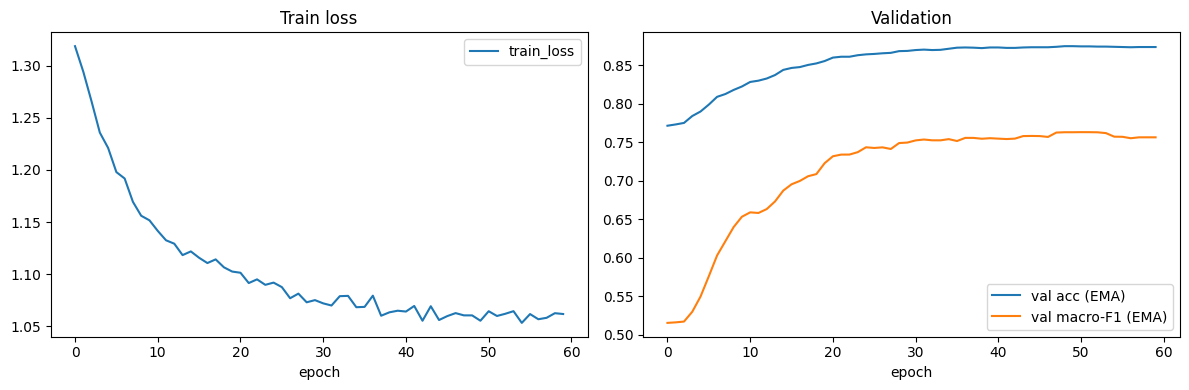

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_full['train_loss'], label='train_loss')
axes[0].set_title('Train loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(hist_full['val_acc'], label='val acc (EMA)')
axes[1].plot(hist_full['val_f1'],  label='val macro-F1 (EMA)')
axes[1].set_title('Validation'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


## Test-time augmentation and probability cache

The same 16-pass TTA recipe as notebook 01 (flip + 5-crop@0.92 + scale 0.95/1.05,
softmax then mean) is applied. The resulting per-image probability vectors are
cached for use by the ensemble notebook.

Test accuracy (TTA): 0.8527
Test macro-F1: 0.6758
              precision    recall  f1-score   support

     Neutral     0.8325    0.9168    0.8726      1274
       Happy     0.9224    0.9591    0.9404       929
    Surprise     0.8559    0.8674    0.8616       445
         Sad     0.7623    0.6256    0.6872       446
       Angry     0.8380    0.8252    0.8315       326
     Disgust     1.0000    0.2609    0.4138        23
        Fear     0.7727    0.3656    0.4964        93
    Contempt     0.8333    0.1852    0.3030        27

    accuracy                         0.8527      3563
   macro avg     0.8521    0.6257    0.6758      3563
weighted avg     0.8501    0.8527    0.8448      3563



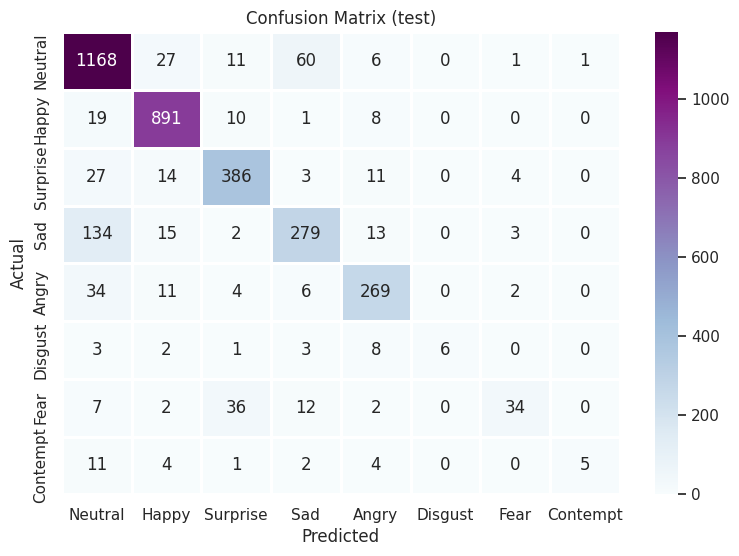

In [20]:
sns.set_theme(style="whitegrid")

def _five_crop(pv, crop_frac=0.92):
    H, W = pv.size(-2), pv.size(-1)
    ch = int(round(H*crop_frac)); cw = int(round(W*crop_frac))
    crops = [
        pv[..., :ch, :cw],
        pv[..., :ch, W-cw:],
        pv[..., H-ch:, :cw],
        pv[..., H-ch:, W-cw:],
        pv[..., (H-ch)//2:(H-ch)//2+ch, (W-cw)//2:(W-cw)//2+cw],
    ]
    return [F.interpolate(c, size=(H, W), mode='bilinear', align_corners=False) for c in crops]

def _scaled(pv, scale):
    H, W = pv.size(-2), pv.size(-1)
    nh, nw = int(round(H*scale)), int(round(W*scale))
    s = F.interpolate(pv, size=(nh, nw), mode='bilinear', align_corners=False)
    return F.interpolate(s, size=(H, W), mode='bilinear', align_corners=False)

@torch.inference_mode()
def predict_with_tta(loader, use_flip=True, use_5crop=True, use_scales=True):
    model.eval()
    yt_chunks, yp_chunks, probs_chunks = [], [], []
    use_amp = (DEVICE == 'cuda')
    def fwd(xdict):
        if use_amp:
            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                return model(**xdict).logits
        return model(**xdict).logits
    for xs, _, hy in loader:
        x = {k: v.to(DEVICE, non_blocking=True) for k,v in xs.items()}
        pv = x['pixel_values']
        ll = [fwd({'pixel_values': pv})]
        if use_flip: ll.append(fwd({'pixel_values': torch.flip(pv, dims=[-1])}))
        if use_5crop:
            for c in _five_crop(pv, 0.92):
                ll.append(fwd({'pixel_values': c}))
                if use_flip: ll.append(fwd({'pixel_values': torch.flip(c, dims=[-1])}))
        if use_scales:
            for s in (0.95, 1.05):
                sv = _scaled(pv, s)
                ll.append(fwd({'pixel_values': sv}))
                if use_flip: ll.append(fwd({'pixel_values': torch.flip(sv, dims=[-1])}))
        # Soft-vote: softmax then mean across augmentations.
        probs = torch.stack([F.softmax(z, dim=-1) for z in ll], dim=0).mean(dim=0)
        probs_chunks.append(probs.float().cpu().numpy())
        yp_chunks.append(probs.argmax(dim=1).cpu().numpy())
        yt_chunks.append(hy.numpy())
    return (np.concatenate(yt_chunks), np.concatenate(yp_chunks),
            np.concatenate(probs_chunks, axis=0))

y_true_val,  y_pred_val,  probs_val_v7  = predict_with_tta(val_loader)
y_true_test, y_pred_test, probs_test_v7 = predict_with_tta(test_loader)

acc = (y_true_test == y_pred_test).mean()
f1  = f1_score(y_true_test, y_pred_test, average='macro')
print(f'Test accuracy (TTA): {acc:.4f}')
print(f'Test macro-F1: {f1:.4f}')

print(classification_report(y_true_test, y_pred_test, labels=list(range(NUM_CLASSES)),
                            target_names=FERP_DISPLAY, digits=4))

cm = confusion_matrix(y_true_test, y_pred_test, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(9, 6))
c = pd.DataFrame(cm, index=FERP_DISPLAY, columns=FERP_DISPLAY)
sns.heatmap(c, linecolor='White', cmap='BuPu', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix (test)'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## Output artifacts

- `fer_v7_ferplus_best.pt` — `{state_dict, val_acc, epoch}` with EMA weights.
- `fer_v7_probs_cache.npz` — `probs_val_v7`, `probs_test_v7`, `yt_val`, `yt_test`.

In [21]:
np.savez_compressed(
    str(ckpt_dir / 'fer_v7_probs_cache.npz'),
    yt_val=y_true_val,
    yt_test=y_true_test,
    probs_val_v7=probs_val_v7,
    probs_test_v7=probs_test_v7,
)
print(f'Probability cache saved: {ckpt_dir / "fer_v7_probs_cache.npz"}')


Probability cache saved: /content/drive/MyDrive/checkpoints/fer_v7_probs_cache.npz
